In [ ]:
# I want to try and see how the variability in high temperature dark field images behaves (ie does it flicker or increase with temp?) 

In [1]:
from pathlib import Path
import pandas as pd
from astropy.io import fits
import numpy as np

folder = Path("/home/bekah/m3_papers/260308_darkcurrent_gifs/flat_fits")

pixels = [
    (39, 20), (55, 64), (14, 40), (100, 44),
    (213, 69), (230, 17), (281, 64), (284, 49), (266, 7)
]

rows = []

for fits_path in folder.glob("*.fits"):

    name = fits_path.name

    # want global 
    if len(name) < 3 or name[2].lower() != "g":
        continue

    file_id = name.split("_")[0]
    with fits.open(fits_path, memmap=True) as hdul:
        data = hdul[0].data  
    n_frames = data.shape[0]

    for frame_i in range(n_frames):
        frame = data[frame_i]

        row = {"id": file_id, "frame": frame_i}

        for (x, y) in pixels:
            row[f"px_{x}_{y}"] = frame[y, x]

        rows.append(row)

df = pd.DataFrame(rows)

In [2]:
df

,id,frame,px_39_20,px_55_64,px_14_40,px_100_44,px_213_69,px_230_17,px_281_64,px_284_49,px_266_7
0,m3g20090416t235041,0,468,527,859,501,520,464,518,507,453
1,m3g20090416t235041,1,535,526,556,515,518,530,518,513,518
2,m3g20090416t235041,2,536,526,556,515,518,531,518,513,518
3,m3g20090416t235041,3,535,527,556,516,518,531,518,513,518
4,m3g20090416t235041,4,535,527,557,516,518,531,518,514,518
...,...,...,...,...,...,...,...,...,...,...,...
112624,m3g20090202t155211,278,530,523,550,509,512,524,514,503,512
112625,m3g20090202t155211,279,531,523,550,509,512,524,514,503,512
112626,m3g20090202t155211,280,531,523,550,509,512,524,514,503,512
112627,m3g20090202t155211,281,531,523,550,509,512,524,514,503,512


In [3]:
# then match to temps 
temps = pd.read_fwf("/home/bekah/m3_papers/20260310_darkcurrent/m3_detector_temperature.tab")

temps["id"] = temps["id"].str.lower()

df = df.merge(temps, left_on="id", right_on="id", how="left")



In [63]:
df[df['temp'] > 162]

,id,frame,px_39_20,px_55_64,px_14_40,px_100_44,px_213_69,px_230_17,px_281_64,px_284_49,px_266_7,temp
1264,m3g20081129t041146,0,489,557,892,530,560,479,555,514,482,165.90
1265,m3g20081129t041146,1,559,560,597,544,556,548,558,518,553,165.90
1266,m3g20081129t041146,2,560,559,596,545,555,548,559,517,551,165.90
1267,m3g20081129t041146,3,560,559,594,543,555,549,558,518,552,165.90
1268,m3g20081129t041146,4,559,559,597,543,554,549,558,518,552,165.90
...,...,...,...,...,...,...,...,...,...,...,...,...
111544,m3g20081212t015112,273,756,731,809,763,774,739,855,636,787,175.64
111545,m3g20081212t015112,274,759,729,809,768,774,735,854,640,786,175.64
111546,m3g20081212t015112,275,761,729,805,766,773,736,856,639,783,175.64
111547,m3g20081212t015112,276,760,730,806,766,775,737,854,638,789,175.64


In [5]:
import matplotlib.pyplot as plt 

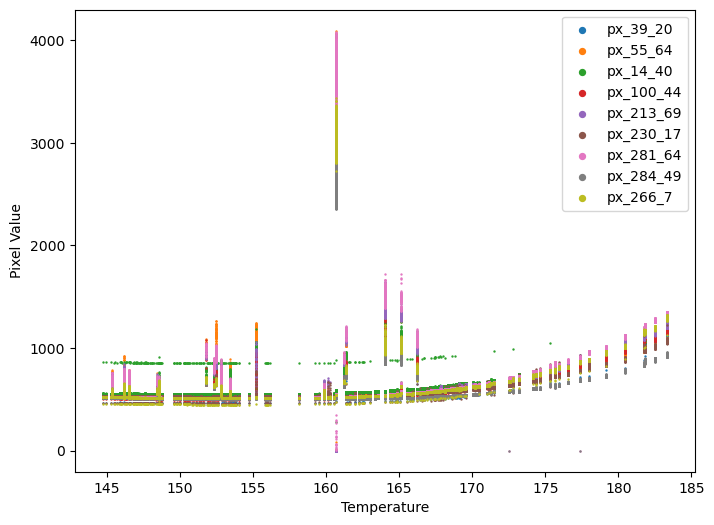

In [7]:

pixel_cols = [
    'px_39_20','px_55_64','px_14_40','px_100_44',
    'px_213_69','px_230_17','px_281_64','px_284_49','px_266_7'
]

plt.figure(figsize=(8,6))

for col in pixel_cols:
    plt.scatter(df['temp'], df[col], s=.5, label=col)

plt.xlabel("Temperature")
plt.ylabel("Pixel Value")
plt.legend(markerscale=6)
plt.show()

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
from astropy.io import fits


pixels = [
    (39,20),(55,64),(14,40),(100,44),
    (213,69),(230,17),(281,64),(284,49),(266,7)
]

rows = []

for f in folder.glob("*.fits"):

    name = f.name
    if name[2].lower() != "g":
        continue

    file_id = name.split("_")[0]

    with fits.open(f, memmap=True) as hdul:
        data = hdul[0].data 

    nframes = data.shape[0]

    row = {"id": file_id}

    for x,y in pixels:

        vals = data[:, y, x]  

        row[f"px_{x}_{y}_mean"] = np.mean(vals)
        row[f"px_{x}_{y}_median"] = np.median(vals)
        row[f"px_{x}_{y}_std"] = np.std(vals)

        if nframes >= 10:
            row[f"px_{x}_{y}_diff5"] = vals[4] - vals[-5]
        else:
            row[f"px_{x}_{y}_diff5"] = np.nan

    rows.append(row)

stats = pd.DataFrame(rows)

In [10]:
stats = stats.merge(temps, left_on="id", right_on="id", how="left")

In [16]:
stats.keys()

Index(['id', 'px_39_20_mean', 'px_39_20_median', 'px_39_20_std',
       'px_39_20_diff5', 'px_55_64_mean', 'px_55_64_median', 'px_55_64_std',
       'px_55_64_diff5', 'px_14_40_mean', 'px_14_40_median', 'px_14_40_std',
       'px_14_40_diff5', 'px_100_44_mean', 'px_100_44_median', 'px_100_44_std',
       'px_100_44_diff5', 'px_213_69_mean', 'px_213_69_median',
       'px_213_69_std', 'px_213_69_diff5', 'px_230_17_mean',
       'px_230_17_median', 'px_230_17_std', 'px_230_17_diff5',
       'px_281_64_mean', 'px_281_64_median', 'px_281_64_std',
       'px_281_64_diff5', 'px_284_49_mean', 'px_284_49_median',
       'px_284_49_std', 'px_284_49_diff5', 'px_266_7_mean', 'px_266_7_median',
       'px_266_7_std', 'px_266_7_diff5', 'temp'],
      dtype='object')

(450.0, 1300.0)

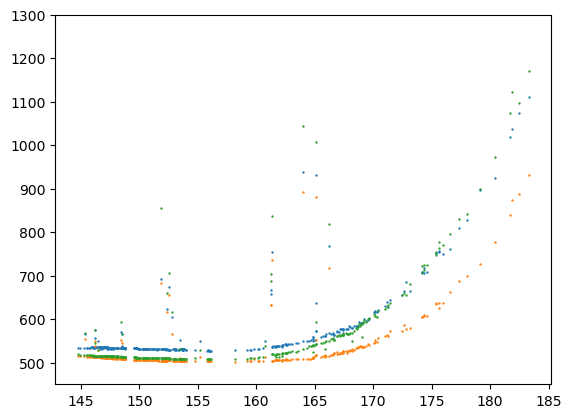

In [20]:
plt.scatter(stats['temp'], stats['px_39_20_mean'],s=.5)
plt.scatter(stats['temp'], stats['px_284_49_mean'],s=.5)
plt.scatter(stats['temp'], stats['px_100_44_mean'],s=.5)
plt.ylim(450,1300)

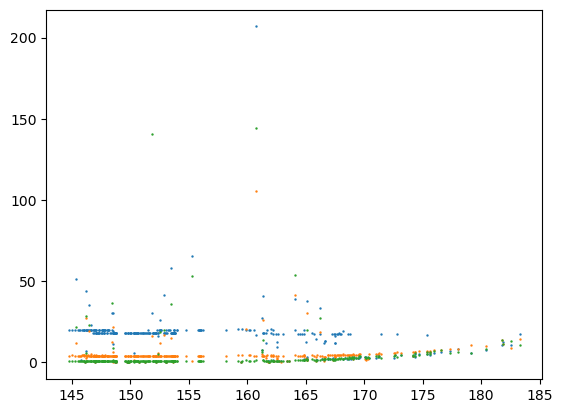

In [24]:
plt.scatter(stats['temp'], stats['px_14_40_std'],s=.5)
plt.scatter(stats['temp'], stats['px_266_7_std'],s=.5)
plt.scatter(stats['temp'], stats['px_100_44_std'],s=.5)


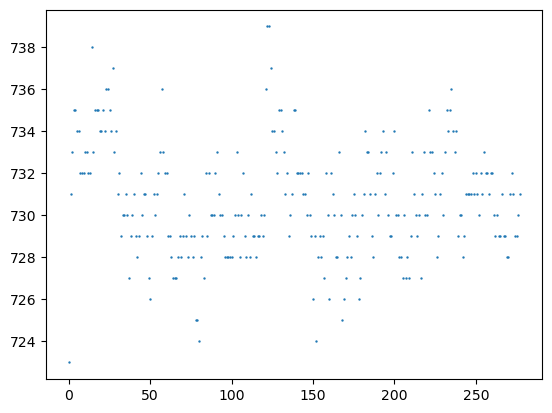

In [31]:
from astropy.io import fits
import matplotlib.pyplot as plt

fits_file = "/home/bekah/m3_papers/260308_darkcurrent_gifs/flat_fits/m3g20081212t015112_l0_flat.fits"

with fits.open(fits_file, memmap=True) as hdul:
    data = hdul[0].data

pixel_series = data[:, 64, 55]   
plt.scatter(range(len(pixel_series)), pixel_series, s=.5)

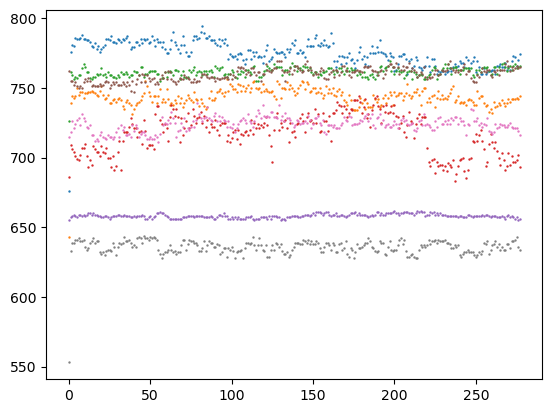

In [49]:
pixel_series = data[:, 23, 145]   
plt.scatter(range(len(pixel_series)), pixel_series, s=.5)
pixel_series2 = data[:, 15, 145]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
pixel_series2 = data[:, 6, 145]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
pixel_series2 = data[:, 45, 200]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
pixel_series2 = data[:, 55, 200]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
pixel_series2 = data[:, 58, 200]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
pixel_series2 = data[:, 42, 221]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
pixel_series2 = data[:, 13, 180]   
plt.scatter(range(len(pixel_series2)), pixel_series2, s=.5)
